# Installing neccessary Librabry

In [ ]:
pip install pandas numpy statsmodels scikit-learn seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load Dataset and Clean

In [3]:
df = pd.read_csv("sales_dataset.csv")

In [4]:
df.head()

,order_id,customer_id,order_date,customer_age,customer_gender,customer_segment,region,state,store_type,product_category,...,competitor_price,economic_index,season,day_of_week,is_holiday,sales_rep_id,sales_rep_experience_years,customer_satisfaction_score,delivery_days,total_sales
0,ORD-101062,CUST-1396,2024-10-02,17.0,Female,Home Office,South West,Ogun,Retail,groceries,...,25403.18,98.89,Rainy,Wednesday,N,REP-05,17.0,2.8,6.0,184238.41
1,ORD-100104,CUST-3191,2024/03/20,58.0,Female,Consumer,South South,WARRI,Retail,Beauty,...,30194.80,97.65,Dry,Wednesday,False,REP-05,11.0,2.6,3.0,144882.33
2,ORD-103564,CUST-3148,2024-04-03,38.0,Female,Corporate,South East,Owerri,Wholesale,Furniture,...,NaN,97.70,Rainy,Wednesday,No,REP-33,10.0,5.0,5.0,87305.62
3,ORD-101207,CUST-2981,"July 09, 2025",44.0,NaN,Consumer,North,PLATEAU,Online,Electronics,...,NaN,93.45,Rainy,Wednesday,No,REP-02,15.0,4.2,4.0,33005.80
4,ORD-103442,CUST-2252,"August 12, 2024",33.0,Female,Corporate,South West,OSUN,Online,Automotive Parts,...,19732.94,102.91,Rainy,Monday,0,REP-08,13.0,2.5,5.0,108238.71


In [5]:
df.shape

(5050, 30)

## Step 1 — First look at the data

Before touching anything, profile it:

In [10]:
df.info()
df.describe(include ="all")


<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     5050 non-null   str    
 1   customer_id                  5050 non-null   str    
 2   order_date                   5050 non-null   str    
 3   customer_age                 4695 non-null   float64
 4   customer_gender              4843 non-null   str    
 5   customer_segment             5050 non-null   str    
 6   region                       5050 non-null   str    
 7   state                        5050 non-null   str    
 8   store_type                   5050 non-null   str    
 9   product_category             5050 non-null   str    
 10  product_subcategory          5050 non-null   str    
 11  product_name                 5050 non-null   str    
 12  unit_price                   5050 non-null   str    
 13  quantity                     

,order_id,customer_id,order_date,customer_age,customer_gender,customer_segment,region,state,store_type,product_category,...,competitor_price,economic_index,season,day_of_week,is_holiday,sales_rep_id,sales_rep_experience_years,customer_satisfaction_score,delivery_days,total_sales
count,5050,5050,5050,4695.000000,4843,5050,5050,5050,5050,5050,...,4020.000000,5050.000000,5050,5050,5050,5050,4902.000000,4430.000000,4830.000000,5.050000e+03
unique,5000,2284,2222,NaN,3,3,5,100,3,28,...,NaN,NaN,2,7,10,60,NaN,NaN,NaN,NaN
top,ORD-103708,CUST-2435,2025-06-28,NaN,Female,Consumer,North Central,Owerri,Online,Furniture,...,NaN,NaN,Rainy,Thursday,no,REP-30,NaN,NaN,NaN,NaN
freq,2,8,11,NaN,2326,2972,1078,85,2756,650,...,NaN,NaN,2957,758,944,102,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,35.196166,NaN,NaN,NaN,NaN,NaN,NaN,...,20550.166769,99.861792,NaN,NaN,NaN,NaN,9.389841,3.796456,5.401449,8.431377e+04
std,NaN,NaN,NaN,13.403844,NaN,NaN,NaN,NaN,NaN,NaN,...,12653.903935,8.013148,NaN,NaN,NaN,NaN,5.777307,0.922631,11.606856,7.631097e+04
min,NaN,NaN,NaN,-18.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,635.000000,74.000000,NaN,NaN,NaN,NaN,0.000000,-1.000000,-5.000000,-1.647462e+05
25%,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,11189.347500,94.560000,NaN,NaN,NaN,NaN,4.000000,3.200000,4.000000,3.604373e+04
50%,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,17648.720000,99.770000,NaN,NaN,NaN,NaN,9.000000,3.800000,5.000000,6.475969e+04
75%,NaN,NaN,NaN,43.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,27478.567500,105.267500,NaN,NaN,NaN,NaN,14.000000,4.400000,6.000000,1.108492e+05


In [16]:
df.isna().sum().sort_values(ascending=False)

competitor_price               1030
customer_satisfaction_score     620
discount_percent                508
loyalty_program_member          390
customer_age                    355
shipping_cost                   310
delivery_days                   220
customer_gender                 207
sales_rep_experience_years      148
region                            0
customer_id                       0
order_id                          0
order_date                        0
customer_segment                  0
quantity                          0
unit_price                        0
product_name                      0
product_subcategory               0
product_category                  0
store_type                        0
state                             0
marketing_channel                 0
economic_index                    0
customer_tenure_months            0
payment_method                    0
season                            0
sales_rep_id                      0
is_holiday                  

In [27]:
df.duplicated().sum()

np.int64(50)

### Columns that are have a missing values are:
    competitor_price  and roughly 20.3960% is missing, which has 1030 out of 5050
    customer_satisfaction_score  and roughly 12.2772% is missing, which has 620 out of 5050     
    discount_percent  and roughly 10.0594% is missing, which has 508 out of 5050
    loyalty_program_member  and roughly 7.7227% is missing, which has 390 out of 5050          
    customer_age  and roughly 7.0297% is missing, which has 355 out of 5050                    
    shipping_cost  and roughly 6.1386% is missing, which has 310 out of 5050                   
    delivery_days  and roughly 4.3564% is missing, which has 220 out of 5050                   
    customer_gender  and roughly 4.0990% is missing, which has 207 out of 5050                 
    sales_rep_experience_years  and roughly 2.9306% is missing, which has 148 out of 5050      

### Which columns *look* numeric but aren't (`dtype: object`):
    No columns looks numeric

### Whether you can see duplicate rows:
    No i cant see duplicate rows but there are actually 50 duplicated rows, when df.duplicated().sum() was run

## Step 2 — Remove duplicates

In [28]:
df = df.drop_duplicates().reset_index(drop=True)

In [30]:
df.shape

(5000, 30)

In [44]:
df["customer_age"].dtype

dtype('float64')

In [37]:
def clean_price(val):
    if isinstance(val, (int, float)):
        return float(val)
    val = str(val).replace("₦", "").replace(",", "").replace("NGN", "").strip()
    return float(val)

In [45]:
df["unit_price"] = df["unit_price"].apply(clean_price)

In [46]:
df["unit_price"].dtype

dtype('float64')

## Step 4 — Parse `order_date` (mixed date formats)

In [47]:
df["order_date"] = pd.to_datetime(df["order_date"], format="mixed")

In [48]:
df["order_date"].dtype

dtype('<M8[us]')

In [49]:
df["order_date"]

0      2024-10-02
1      2024-03-20
2      2024-04-03
3      2025-07-09
4      2024-08-12
          ...    
4995   2025-02-10
4996   2025-01-12
4997   2024-04-08
4998   2025-05-27
4999   2024-11-19
Name: order_date, Length: 5000, dtype: datetime64[us]

## Step 5 — Standardize messy categoricals

In [51]:
df.head(8)

,order_id,customer_id,order_date,customer_age,customer_gender,customer_segment,region,state,store_type,product_category,...,competitor_price,economic_index,season,day_of_week,is_holiday,sales_rep_id,sales_rep_experience_years,customer_satisfaction_score,delivery_days,total_sales
0,ORD-101062,CUST-1396,2024-10-02,17.0,Female,Home Office,South West,Ogun,Retail,groceries,...,25403.18,98.89,Rainy,Wednesday,N,REP-05,17.0,2.8,6.0,184238.41
1,ORD-100104,CUST-3191,2024-03-20,58.0,Female,Consumer,South South,WARRI,Retail,Beauty,...,30194.80,97.65,Dry,Wednesday,False,REP-05,11.0,2.6,3.0,144882.33
2,ORD-103564,CUST-3148,2024-04-03,38.0,Female,Corporate,South East,Owerri,Wholesale,Furniture,...,NaN,97.70,Rainy,Wednesday,No,REP-33,10.0,5.0,5.0,87305.62
3,ORD-101207,CUST-2981,2025-07-09,44.0,NaN,Consumer,North,PLATEAU,Online,Electronics,...,NaN,93.45,Rainy,Wednesday,No,REP-02,15.0,4.2,4.0,33005.80
4,ORD-103442,CUST-2252,2024-08-12,33.0,Female,Corporate,South West,OSUN,Online,Automotive Parts,...,19732.94,102.91,Rainy,Monday,0,REP-08,13.0,2.5,5.0,108238.71
5,ORD-104409,CUST-1888,2024-04-07,44.0,Male,Home Office,North Central,Ilorin,Retail,FURNITURE,...,4147.65,104.26,Rainy,Sunday,No,REP-34,3.0,4.4,9.0,-6005.57
6,ORD-102836,CUST-3654,2024-09-10,21.0,Male,Consumer,North,Kano,Retail,Electronics,...,29418.42,92.45,Rainy,Wednesday,no,REP-32,15.0,3.0,3.0,51558.21
7,ORD-101559,CUST-3352,2024-03-17,44.0,Female,Home Office,South West,lagos,Online,Clothing,...,38670.43,102.69,Dry,Sunday,No,REP-02,6.0,4.1,6.0,139252.63


In [52]:
text_cols = ["state", "product_category", "payment_method", "region",
             "customer_segment", "store_type", "marketing_channel"]

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace("_", "")
        .str.title()
    )

In [53]:
df["state"].unique

<bound method Series.unique of 0          Ogun
1         Warri
2        Owerri
3       Plateau
4          Osun
         ...   
4995    Onitsha
4996     Ilorin
4997      Abuja
4998     Ilorin
4999        Jos
Name: state, Length: 5000, dtype: str>

In [54]:
df["product_category"].unique

<bound method Series.unique of 0              Groceries
1                 Beauty
2              Furniture
3            Electronics
4       Automotive Parts
              ...       
4995    Automotive Parts
4996         Electronics
4997         Electronics
4998     Office Supplies
4999         Electronics
Name: product_category, Length: 5000, dtype: str>

In [55]:
df["payment_method"].unique

<bound method Series.unique of 0       Bank Transfer
1          Debit Card
2                Ussd
3                Ussd
4                Ussd
            ...      
4995     Mobile Money
4996      Credit Card
4997      Credit Card
4998       Debit Card
4999       Creditcard
Name: payment_method, Length: 5000, dtype: str>

In [57]:
df["state"].nunique()

25

## Step 6 — Standardize boolean columns

In [58]:
df["loyalty_program_member"]

0           N
1         NaN
2         NaN
3         Yes
4         NaN
        ...  
4995      yes
4996    False
4997      NaN
4998    False
4999        Y
Name: loyalty_program_member, Length: 5000, dtype: str

In [59]:
df["is_holiday"]

0           N
1       False
2          No
3          No
4           0
        ...  
4995        0
4996       no
4997      yes
4998    False
4999    False
Name: is_holiday, Length: 5000, dtype: str

In [78]:
true_values = {"yes", "y", "1", "true"}

def to_bool(val):
    if pd.isna(val):
        return np.nan
    return str(val).strip().lower() in true_values

In [71]:
df["loyalty_program_member"] = df["loyalty_program_member"].apply(to_bool)

In [72]:
df["is_holiday"] = df["is_holiday"].apply(to_bool)

In [73]:
df["is_holiday"].dtype

dtype('bool')

In [75]:
df["loyalty_program_member"].dtype

dtype('O')

## Step 7 — Handle invalid / impossible values

In [79]:
df.loc[(df["customer_age"] < 0) | (df["customer_age"] > 100), "customer_age"] = np.nan
df.loc[(df["quantity"] <= 0), "quantity"] = np.nan
df["discount_percent"] = df["discount_percent"].clip(0, 100)
df["customer_satisfaction_score"] = df["customer_satisfaction_score"].clip(1, 5)
df.loc[(df["delivery_days"] < 0) | (df["delivery_days"] > 60), "delivery_days"] = np.nan
df = df[df["total_sales"] >= 0] 


In [83]:
df.shape

(4995, 30)

## Step 8 — Decide on rare, extreme `total_sales` outliers

In [84]:
df["total_sales"].describe

<bound method NDFrame.describe of 0       184238.41
1       144882.33
2        87305.62
3        33005.80
4       108238.71
          ...    
4995     30747.10
4996    137752.31
4997    144595.85
4998     18476.81
4999     35370.86
Name: total_sales, Length: 4995, dtype: float64>

<Axes: xlabel='total_sales'>

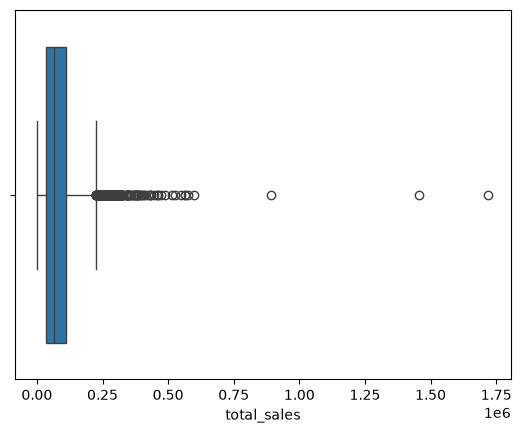

In [85]:
sns.boxplot(x=df["total_sales"])

In [86]:
cap = df["total_sales"].quantile(0.99)

In [88]:
 df["total_sales"] =  df["total_sales"].clip(upper=cap)

## Reason for chosing **Cap (winsorize)** at the 99th percentile

##### I chose to cap (Winsorize) the data at the 99th percentile. Since we are dealing with sales, these extreme outliers represent valid but unusual transactions that we want to keep without letting them skew the model.

## Step 9 — Exploratory Data Analysis


In [90]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].corr()["total_sales"].sort_values(ascending=False)

total_sales                    1.000000
unit_price                     0.743374
competitor_price               0.736131
sales_rep_experience_years     0.051647
quantity                       0.028631
economic_index                 0.027048
customer_satisfaction_score    0.013707
customer_tenure_months        -0.006051
shipping_cost                 -0.010221
customer_age                  -0.013020
delivery_days                 -0.013716
discount_percent              -0.112388
Name: total_sales, dtype: float64

<Axes: xlabel='unit_price', ylabel='total_sales'>

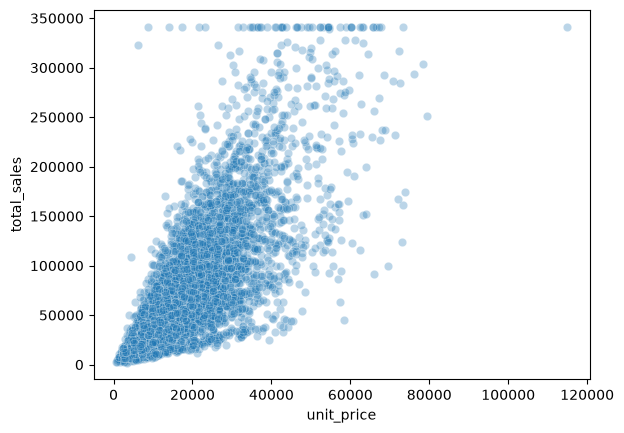

In [94]:
sns.scatterplot(data=df, x="unit_price", y="total_sales", alpha=0.3)

<Axes: xlabel='competitor_price', ylabel='total_sales'>

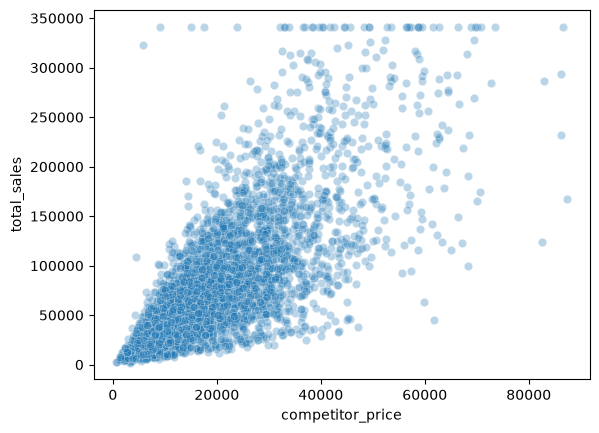

In [93]:
sns.scatterplot(data=df, x="competitor_price", y="total_sales", alpha=0.3)

In [95]:
df["discount_percent"]

0        0.0
1        5.0
2        NaN
3       10.0
4        0.0
        ... 
4995    30.0
4996     5.0
4997     NaN
4998     NaN
4999     0.0
Name: discount_percent, Length: 4995, dtype: float64

<Axes: xlabel='discount_percent', ylabel='total_sales'>

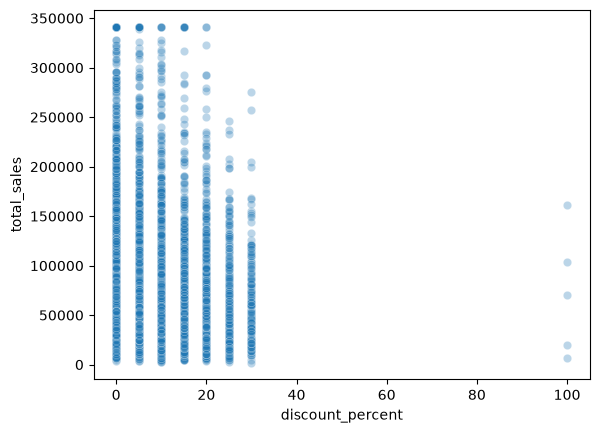

In [97]:
sns.scatterplot(data=df, x="discount_percent", y="total_sales", alpha=0.3)

In [98]:
df.columns

Index(['order_id', 'customer_id', 'order_date', 'customer_age',
       'customer_gender', 'customer_segment', 'region', 'state', 'store_type',
       'product_category', 'product_subcategory', 'product_name', 'unit_price',
       'quantity', 'discount_percent', 'shipping_cost', 'payment_method',
       'marketing_channel', 'customer_tenure_months', 'loyalty_program_member',
       'competitor_price', 'economic_index', 'season', 'day_of_week',
       'is_holiday', 'sales_rep_id', 'sales_rep_experience_years',
       'customer_satisfaction_score', 'delivery_days', 'total_sales'],
      dtype='str')

<Axes: xlabel='product_category', ylabel='total_sales'>

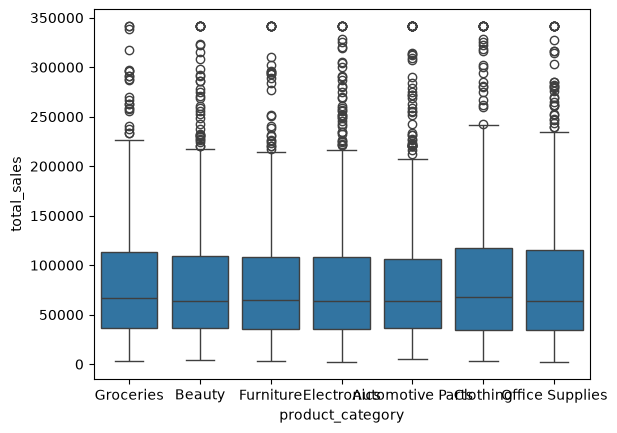

In [99]:
sns.boxplot(data=df, x="product_category", y="total_sales")

<Axes: xlabel='loyalty_program_member', ylabel='total_sales'>

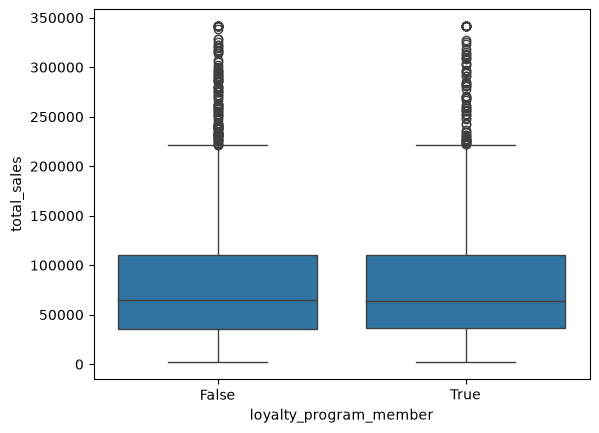

In [100]:
sns.boxplot(data=df, x="loyalty_program_member", y="total_sales")

## Step 10 — Feature engineering

In [102]:
df["order_month"] = df["order_date"].dt.month
df["order_month"]

0       10
1        3
2        4
3        7
4        8
        ..
4995     2
4996     1
4997     4
4998     5
4999    11
Name: order_month, Length: 4995, dtype: int32

In [104]:
df["days_of_the_week"] = df["order_date"].dt.dayofweek
df["days_of_the_week"]

0       2
1       2
2       2
3       2
4       0
       ..
4995    0
4996    6
4997    0
4998    1
4999    1
Name: days_of_the_week, Length: 4995, dtype: int32

In [105]:
df["is_weekend"] = df["days_of_the_week"].isin([5, 6])
df["is_weekend"]

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996     True
4997    False
4998    False
4999    False
Name: is_weekend, Length: 4995, dtype: bool

In [109]:
df["price_after_discount"] = df["unit_price"] * (1 - df["discount_percent"] /100)
df["price_after_discount"]

0       24579.5000
1       25525.9395
2              NaN
3        4882.1850
4       22502.3300
           ...    
4995     7834.4910
4996    43464.6090
4997           NaN
4998           NaN
4999    11400.0200
Name: price_after_discount, Length: 4995, dtype: float64

In [110]:
df["price_vs_competitor"] = df["unit_price"] - df["competitor_price"]
df["price_vs_competitor"]

0       -823.68
1      -3325.39
2           NaN
3           NaN
4       2769.39
         ...   
4995    -774.79
4996        NaN
4997        NaN
4998    -310.51
4999        NaN
Name: price_vs_competitor, Length: 4995, dtype: float64

In [111]:
df["day_of_week"]

0       Wednesday
1       Wednesday
2       Wednesday
3       Wednesday
4          Monday
          ...    
4995       Monday
4996       Sunday
4997       Monday
4998      Tuesday
4999      Tuesday
Name: day_of_week, Length: 4995, dtype: str

In [112]:
drop_cols = ["order_id", "customer_id", "product_name", "sales_rep_id",
             "order_date", "day_of_week"]  # day_of_week duplicates order_dayofweek
df = df.drop(columns=drop_cols)

In [114]:
df.columns

Index(['customer_age', 'customer_gender', 'customer_segment', 'region',
       'state', 'store_type', 'product_category', 'product_subcategory',
       'unit_price', 'quantity', 'discount_percent', 'shipping_cost',
       'payment_method', 'marketing_channel', 'customer_tenure_months',
       'loyalty_program_member', 'competitor_price', 'economic_index',
       'season', 'is_holiday', 'sales_rep_experience_years',
       'customer_satisfaction_score', 'delivery_days', 'total_sales',
       'order_month', 'days_of_the_week', 'is_weekend', 'price_after_discount',
       'price_vs_competitor'],
      dtype='str')

In [115]:
df.shape

(4995, 29)

## Step 11 — Train/test split

In [116]:
X = df.drop(columns=["total_sales"])
y = df["total_sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 12 — Build the preprocessing pipeline

In [121]:
numeric_features = X.select_dtypes(include=np.number).columns.to_list()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.to_list()
boolean_features = ["loyalty_program_member", "is_holiday"]

In [123]:
numerical_features = [c for c in numeric_features if c not in boolean_features]
categorical_features = [c for c in categorical_features if c not in boolean_features]

In [139]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", OneHotEncoder(handle_unknown="ignore")),
])


boolean_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

In [140]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features),
    ("bool", boolean_transformer, boolean_features)
])

## Step 13 — Baseline model

In [142]:
baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])


baseline.fit(X_train, y_train)
preds = baseline.predict(X_test)

In [143]:
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", mean_squared_error(y_test, preds) ** 0.5)
print("R²:", r2_score(y_test, preds))

MAE: 30246.320870369615
RMSE: 42787.042793860295
R²: 0.5649061840139528


## Step 14 — Try stronger models

In [144]:
models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

In [145]:
results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
    results[name] = scores.mean()
    print(f"{name}: R² = {scores.mean():.3f} (+/- {scores.std():.3f})")

Ridge: R² = 0.546 (+/- 0.019)
RandomForest: R² = 0.921 (+/- 0.017)
GradientBoosting: R² = 0.929 (+/- 0.016)


In [146]:
pipe = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", GradientBoostingRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],  # How many sequential trees to build
    "model__learning_rate": [0.01, 0.1, 0.2], # How fast the model learns from its mistakes
    "model__max_depth": [3, 4, 5]             # How deep/complex each tree is allowed to get
}

tuner = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=3,           # We use 3 instead of 5 here just to make it run faster!
    scoring="r2",
    n_jobs=-1       # This tells your computer to use all its CPU cores
)
tuner.fit(X_train, y_train)

# # 5. Reveal the winning combination
# print(f"The Best R² Score: {tuner.best_score_:.3f}")
# print(f"The Best Settings: {tuner.best_params_}")

print("Best params:", tuner.best_params_)
print("Best CV R²:", tuner.best_score_)

Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV R²: 0.9254056139975843


## Step 16 — Final evaluation on the test set

Final MAE: 9333.83181490626
Final RMSE: 16377.301266048113
Final R²: 0.9362554522977602


Text(0, 0.5, 'Residual')

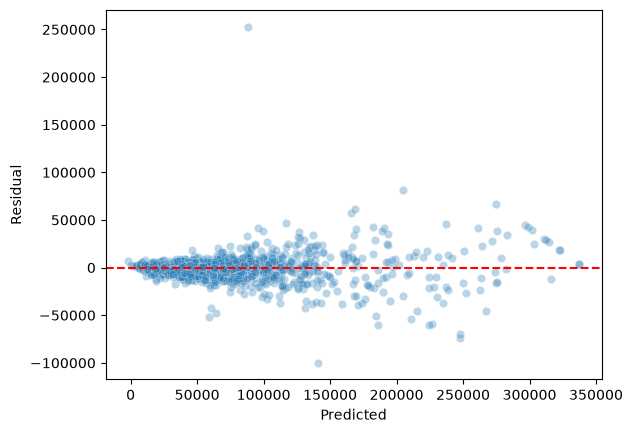

In [147]:
best_model = tuner.best_estimator_
final_preds = best_model.predict(X_test)

print("Final MAE:", mean_absolute_error(y_test, final_preds))
print("Final RMSE:", mean_squared_error(y_test, final_preds) ** 0.5)
print("Final R²:", r2_score(y_test, final_preds))

# Residual plot — look for patterns that suggest a missing feature or non-linearity
residuals = y_test - final_preds
sns.scatterplot(x=final_preds, y=residuals, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")

## Step 17 — Feature importance

In [154]:
# 2. Extract the actual Gradient Boosting algorithm from the end of the pipeline
gb_model = best_model.named_steps["model"]

# 3. Extract the clean column names from the preprocessor step
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# 4. Create a clean table pairing the column names with their "Importance Score"
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances.head(15)

,Feature,Importance
1,num__unit_price,0.571424
2,num__quantity,0.348705
13,num__price_after_discount,0.053531
3,num__discount_percent,0.011534
8,num__sales_rep_experience_years,0.004084
5,num__customer_tenure_months,0.002098
31,cat__state_Ekiti,0.001683
6,num__competitor_price,0.000648
12,num__days_of_the_week,0.000571
70,cat__product_subcategory_Footwear,0.000531


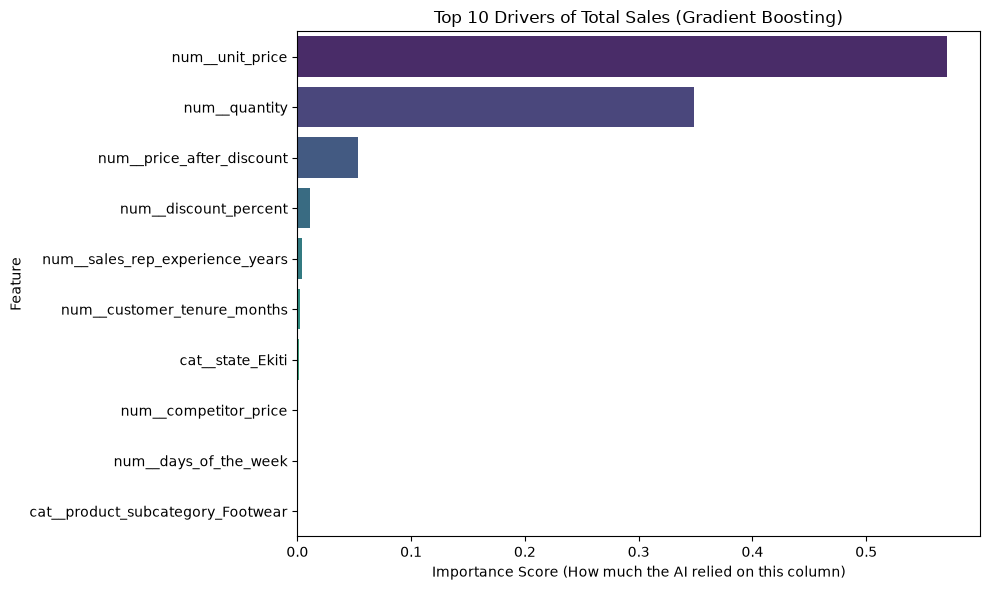

In [155]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
plt.title("Top 10 Drivers of Total Sales (Gradient Boosting)")
plt.xlabel("Importance Score (How much the AI relied on this column)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()